# Assignment 8: CNN Image Classification — Geometric Shapes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dibakar1612/CNN-ImageClassification/blob/main/Final_Lab/CNN/220125_CNN.ipynb)

**Student Name:** Dibakar Sarker Akash  
**Student ID:** 220125  
**Registration No:** 2201024  
**Session:** 2022–2023  
**Department:** Department of Computer Science and Engineering  
**Institution:** Jashore University of Science and Technology (JUST)  
**Course:** CSE-3208: Pattern Recognition & Machine Learning Lab  
**Assignment:** Assignment 8 — Convolutional Neural Network (CNN) Shape Classification  
**Dataset Option:** Option 5 — Geometric Shapes (Circle, Square, Triangle)  
**Repository:** [https://github.com/dibakar1612/CNN-ImageClassification](https://github.com/dibakar1612/CNN-ImageClassification)  
**Branch:** `main`

---

## 1. Project Objectives & Pipeline Overview
1. **Google Colab & Local Portability:** Automatic environment discovery supporting local workstations and Google Colab cloud runtimes.
2. **Single Shared Preprocessing:** Enforces an identical transformation pipeline ($64 	imes 64$ RGB resize, PyTorch tensor conversion, and $[-1.0, 1.0]$ normalization) across training, validation, testing, and real-world smartphone photographs.
3. **Deep CNN Architecture:** 2-stage hierarchical feature extractor (Conv + ReLU + MaxPool) with dense classification head ($2,117,059$ parameters).
4. **Comprehensive Evaluation:** Generates Accuracy vs. Epochs (`AvE.png`), Loss vs. Epochs (`LvE.png`), Confusion Matrix (`confusion_matrix.png`), Custom Predictions (`custom_predictions.png`), and Error Analysis (`error_analysis.png`).
5. **Real-World Smartphone Generalization:** Evaluates out-of-distribution performance on 10 hand-drawn smartphone camera photographs.


## 2. Environment Setup & Directory Resolution
This cell initializes deterministic random seeds for experimental reproducibility and resolves project dataset directories.


In [36]:


import os
import sys
import random
import json

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    DataLoader,
    WeightedRandomSampler
)

from torchvision import (
    datasets,
    transforms
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)




SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)




device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(
    f"Active Device: {device}"
)




def resolve_working_root():

    candidates = [

        ".",

        "CNN",

        "Final_Lab/CNN",

        "Final_Lab",

        "CNN-ImageClassification/Final_Lab/CNN",

        "CNN-ImageClassification",

        "/content/CNN-ImageClassification/Final_Lab/CNN",

        "/content/CNN-ImageClassification",

        "/content"
    ]




    for candidate in candidates:

        dataset_dir = os.path.join(
            candidate,
            "dataset"
        )

        if (
            os.path.isdir(dataset_dir)
            and
            len(os.listdir(dataset_dir)) > 0
        ):

            return os.path.abspath(
                candidate
            )




    repo_dir = "CNN-ImageClassification"

    if not os.path.exists(repo_dir):

        print(
            "Repository not found."
        )

        print(
            "Cloning GitHub repository..."
        )

        os.system(
            "git clone "
            "https://github.com/dibakar1612/"
            "CNN-ImageClassification.git"
        )




    for candidate in candidates:

        dataset_dir = os.path.join(
            candidate,
            "dataset"
        )

        if (
            os.path.isdir(dataset_dir)
            and
            len(os.listdir(dataset_dir)) > 0
        ):

            return os.path.abspath(
                candidate
            )


    raise FileNotFoundError(
        "Could not locate the "
        "CNN-ImageClassification repository."
    )


ROOT = resolve_working_root()


TRAIN_DIR = os.path.join(
    ROOT,
    "training",
    "train"
)

VAL_DIR = os.path.join(
    ROOT,
    "training",
    "validation"
)

TEST_DIR = os.path.join(
    ROOT,
    "training",
    "test"
)

CUSTOM_DIR = os.path.join(
    ROOT,
    "dataset"
)

MODEL_DIR = os.path.join(
    ROOT,
    "model"
)

RESULTS_DIR = os.path.join(
    ROOT,
    "results"
)



os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)



required_directories = [

    TRAIN_DIR,

    VAL_DIR,

    TEST_DIR,

    CUSTOM_DIR
]


for directory in required_directories:

    if not os.path.isdir(directory):

        raise FileNotFoundError(
            f"\nRequired directory not found:\n"
            f"{directory}\n\n"
            "Please verify the GitHub repository "
            "contains the required dataset folders."
        )




print(
    "\nDataset directories verified successfully."
)

print(
    f"\nProject Root: {ROOT}"
)

print(
    f"Training:    {TRAIN_DIR}"
)

print(
    f"Validation:  {VAL_DIR}"
)

print(
    f"Test:        {TEST_DIR}"
)

print(
    f"Custom:      {CUSTOM_DIR}"
)

print(
    f"Model:       {MODEL_DIR}"
)

print(
    f"Results:     {RESULTS_DIR}"
)

Active Device: cpu

Dataset directories verified successfully.

Project Root: /content/CNN-ImageClassification
Training:    /content/CNN-ImageClassification/training/train
Validation:  /content/CNN-ImageClassification/training/validation
Test:        /content/CNN-ImageClassification/training/test
Custom:      /content/CNN-ImageClassification/dataset
Model:       /content/CNN-ImageClassification/model
Results:     /content/CNN-ImageClassification/results


## 3. Single Shared Preprocessing Pipeline & DataLoaders
All images (training, validation, standard test, and custom smartphone photographs) pass through the identical transformation pipeline:
- `Resize((64, 64))`: Standardizes spatial dimensions to $64 	imes 64$ RGB images.
- `ToTensor()`: Converts PIL RGB images ($H 	imes W 	imes C$) to PyTorch float tensors ($C 	imes H 	imes W$) scaled to $[0.0, 1.0]$.
- `Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))`: Normalizes pixel values into $[-1.0, 1.0]$ via $x_{norm} = rac{x - 0.5}{0.5}$.


In [37]:
import os
import sys
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, WeightedRandomSampler

from torchvision import datasets, transforms

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)



SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Device: {device}")


def resolve_working_root():

    candidates = [
        ".",
        "CNN",
        "Final_Lab/CNN",
        "Final_Lab",
        "CNN-ImageClassification/Final_Lab/CNN",
        "CNN-ImageClassification",
        "/content/CNN-ImageClassification/Final_Lab/CNN",
        "/content/CNN-ImageClassification",
        "/content"
    ]

    # Check current environment
    for c in candidates:
        dataset_dir = os.path.join(c, "dataset")

        if os.path.isdir(dataset_dir) and len(os.listdir(dataset_dir)) > 0:
            return os.path.abspath(c)

    # Clone repository in fresh Colab
    repo_dir = "CNN-ImageClassification"

    if not os.path.exists(repo_dir):

        print("Cloning GitHub repository...")

        os.system(
            "git clone https://github.com/dibakar1612/CNN-ImageClassification.git"
        )

    # Search again after cloning
    for c in candidates:

        dataset_dir = os.path.join(c, "dataset")

        if os.path.isdir(dataset_dir) and len(os.listdir(dataset_dir)) > 0:
            return os.path.abspath(c)

    raise FileNotFoundError(
        "Could not locate the CNN-ImageClassification repository."
    )


ROOT = resolve_working_root()



TRAIN_DIR = os.path.join(ROOT, "training", "train")
VAL_DIR = os.path.join(ROOT, "training", "validation")
TEST_DIR = os.path.join(ROOT, "training", "test")

CUSTOM_DIR = os.path.join(ROOT, "dataset")
MODEL_DIR = os.path.join(ROOT, "model")
RESULTS_DIR = os.path.join(ROOT, "results")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)



required_dirs = [
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR,
    CUSTOM_DIR
]

for directory in required_dirs:

    if not os.path.isdir(directory):

        raise FileNotFoundError(
            f"Required directory not found:\n{directory}"
        )

print("\nDataset directories verified successfully.")

print(f"\nProject Root: {ROOT}")
print(f"Training:    {TRAIN_DIR}")
print(f"Validation:  {VAL_DIR}")
print(f"Test:        {TEST_DIR}")
print(f"Custom:      {CUSTOM_DIR}")
print(f"Model:       {MODEL_DIR}")
print(f"Results:     {RESULTS_DIR}")

Active Device: cpu

Dataset directories verified successfully.

Project Root: /content/CNN-ImageClassification
Training:    /content/CNN-ImageClassification/training/train
Validation:  /content/CNN-ImageClassification/training/validation
Test:        /content/CNN-ImageClassification/training/test
Custom:      /content/CNN-ImageClassification/dataset
Model:       /content/CNN-ImageClassification/model
Results:     /content/CNN-ImageClassification/results


## 4. CNN Architecture
The custom Convolutional Neural Network inherits from `nn.Module` and processes $64 	imes 64 	imes 3$ RGB inputs:
- **Conv Layer 1:** 3 input channels $	o$ 32 output channels, kernel $3 	imes 3$, padding 1 $	o$ `ReLU()` $	o$ `MaxPool2d(2)` ($32 	imes 32 	imes 32$)
- **Conv Layer 2:** 32 input channels $	o$ 64 output channels, kernel $3 	imes 3$, padding 1 $	o$ `ReLU()` $	o$ `MaxPool2d(2)` ($64 	imes 16 	imes 16$)
- **Flatten:** $64 	imes 16 	imes 16 = 16,384$ flattened feature map
- **FC Layer 1:** Linear ($16,384 	o 128$) $	o$ `ReLU()`
- **FC Layer 2:** Linear ($128 	o 3$) output logits for Circles, Squares, Triangles


In [38]:

# IMPROVED CNN MODEL


class ShapeCNN(nn.Module):

    def __init__(self, num_classes=3):

        super(ShapeCNN, self).__init__()



        self.block1 = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        self.block2 = nn.Sequential(

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )



        self.block3 = nn.Sequential(

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )



        self.global_pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )



        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(inplace=True),

            nn.Dropout(
                p=0.30
            ),

            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):

        x = self.block1(x)

        x = self.block2(x)

        x = self.block3(x)

        x = self.global_pool(x)

        x = self.classifier(x)

        return x




model = ShapeCNN(
    num_classes=len(class_names)
).to(device)

print(model)




total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"\nTotal Parameters: {total_params:,}"
)

print(
    f"Trainable Parameters: {trainable_params:,}"
)

ShapeCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequen

## 5. Model Training & Load-if-Present Mechanism
- **Criterion:** `nn.CrossEntropyLoss()`
- **Optimizer:** `optim.Adam(lr=0.001)`
- **Epochs:** 10
- **Weight Management:** If saved weights `model/220125.pth` exist, they are loaded directly. Otherwise, the model trains for 10 epochs and saves the weights.


In [39]:
#
# DATA PREPROCESSING


IMAGE_SIZE = 64


# Base preprocessing


base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

# Training augmentation


train_transform = transforms.Compose([

    transforms.Resize((72, 72)),

    transforms.RandomResizedCrop(
        size=(IMAGE_SIZE, IMAGE_SIZE),
        scale=(0.75, 1.0),
        ratio=(0.90, 1.10)
    ),

    transforms.RandomRotation(
        degrees=30
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.12, 0.12),
        scale=(0.90, 1.10),
        shear=8
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.20
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])


# Validation/Test


eval_transform = base_transform

# DATASETS


train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=eval_transform
)

# Class names


class_names = train_dataset.classes

print("\nClass Mapping:")
for index, name in enumerate(class_names):
    print(f"{index}: {name}")


# HANDLE CLASS IMBALANCE

train_targets = np.array(train_dataset.targets)

class_counts = np.bincount(train_targets)

print("\nTraining Class Distribution:")

for index, count in enumerate(class_counts):
    print(f"{class_names[index]:10s}: {count}")

# Calculate weight for every class
class_weights = 1.0 / class_counts

# Assign weight to every training sample
sample_weights = class_weights[train_targets]

sample_weights = torch.as_tensor(
    sample_weights,
    dtype=torch.double
)

# WeightedRandomSampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DATALOADERS

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=sampler,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

print("\nDataset Summary:")
print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples:       {len(test_dataset)}")


Class Mapping:
0: circles
1: squares
2: triangles

Training Class Distribution:
circles   : 304
squares   : 103
triangles : 136

Dataset Summary:
Training samples:   543
Validation samples: 180
Test samples:       90


In [32]:
# MODEL TRAINING

# 1. LOSS FUNCTION

criterion = nn.CrossEntropyLoss()


# 2. OPTIMIZER

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


# 3. LEARNING-RATE SCHEDULER

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)



epochs = 30

model_path = os.path.join(
    MODEL_DIR,
    "220125.pth"
)




history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}




best_val_acc = 0.0

best_epoch = 0




print(
    "\n============================================================"
)

print(
    "STARTING CNN TRAINING"
)

print(
    "============================================================"
)

print(
    f"Device: {device}"
)

print(
    f"Epochs: {epochs}"
)

print(
    f"Batch size: {batch_size}"
)

print(
    f"Training samples: {len(train_dataset)}"
)

print(
    f"Validation samples: {len(val_dataset)}"
)

print(
    "============================================================\n"
)


for epoch in range(epochs):

    #
    model.train()

    running_train_loss = 0.0

    train_correct = 0

    train_total = 0


    for images, labels in train_loader:



        images = images.to(device)

        labels = labels.to(device)




        optimizer.zero_grad()




        outputs = model(images)


        #

        loss = criterion(
            outputs,
            labels
        )



        loss.backward()



        optimizer.step()




        running_train_loss += (
            loss.item()
            *
            images.size(0)
        )

        _, predictions = torch.max(
            outputs,
            1
        )

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)



    train_loss = (
        running_train_loss
        /
        train_total
    )

    train_acc = (
        train_correct
        /
        train_total
    ) * 100.0




    model.eval()

    running_val_loss = 0.0

    val_correct = 0

    val_total = 0


    with torch.no_grad():

        for images, labels in val_loader:


            images = images.to(device)

            labels = labels.to(device)



            outputs = model(images)



            loss = criterion(
                outputs,
                labels
            )


            running_val_loss += (
                loss.item()
                *
                images.size(0)
            )



            _, predictions = torch.max(
                outputs,
                1
            )


            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)




    val_loss = (
        running_val_loss
        /
        val_total
    )

    val_acc = (
        val_correct
        /
        val_total
    ) * 100.0



    history["train_loss"].append(
        train_loss
    )

    history["train_acc"].append(
        train_acc
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_acc"].append(
        val_acc
    )



    scheduler.step(
        val_acc
    )


    current_lr = optimizer.param_groups[0]["lr"]




    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            model_path
        )

        best_marker = "  <-- BEST MODEL SAVED"

    else:

        best_marker = ""


    print(
        f"Epoch [{epoch + 1:02d}/{epochs}] "
        f"| "
        f"Train Loss: {train_loss:.4f} "
        f"| "
        f"Train Acc: {train_acc:.2f}% "
        f"| "
        f"Val Loss: {val_loss:.4f} "
        f"| "
        f"Val Acc: {val_acc:.2f}% "
        f"| "
        f"LR: {current_lr:.6f}"
        f"{best_marker}"
    )




history_path = os.path.join(
    RESULTS_DIR,
    "220125_history.json"
)

with open(
    history_path,
    "w"
) as f:

    json.dump(
        history,
        f,
        indent=4
    )



if os.path.exists(model_path):

    model.load_state_dict(
        torch.load(
            model_path,
            map_location=device
        )
    )

    print(
        "\nBest model loaded successfully."
    )

else:

    print(
        "\nWARNING: Best model file was not found."
    )


# 10. FINAL TRAINING SUMMARY

print(
    "\n============================================================"
)

print(
    "TRAINING COMPLETED"
)

print(
    "============================================================"
)

print(
    f"Best Validation Accuracy: "
    f"{best_val_acc:.2f}%"
)

print(
    f"Best Epoch: {best_epoch}"
)

print(
    f"Model saved at:\n{model_path}"
)

print(
    f"History saved at:\n{history_path}"
)

print(
    "============================================================"
)


STARTING CNN TRAINING
Device: cpu
Epochs: 30
Batch size: 32
Training samples: 543
Validation samples: 180

Epoch [01/30] | Train Loss: 0.9245 | Train Acc: 54.33% | Val Loss: 1.1356 | Val Acc: 41.67% | LR: 0.001000  <-- BEST MODEL SAVED
Epoch [02/30] | Train Loss: 0.6732 | Train Acc: 71.82% | Val Loss: 0.9475 | Val Acc: 52.22% | LR: 0.001000  <-- BEST MODEL SAVED
Epoch [03/30] | Train Loss: 0.5654 | Train Acc: 72.74% | Val Loss: 0.9226 | Val Acc: 53.89% | LR: 0.001000  <-- BEST MODEL SAVED
Epoch [04/30] | Train Loss: 0.4929 | Train Acc: 77.72% | Val Loss: 0.3245 | Val Acc: 85.56% | LR: 0.001000  <-- BEST MODEL SAVED
Epoch [05/30] | Train Loss: 0.4379 | Train Acc: 78.82% | Val Loss: 0.2369 | Val Acc: 89.44% | LR: 0.001000  <-- BEST MODEL SAVED
Epoch [06/30] | Train Loss: 0.3936 | Train Acc: 83.24% | Val Loss: 0.9523 | Val Acc: 68.89% | LR: 0.001000
Epoch [07/30] | Train Loss: 0.3642 | Train Acc: 86.19% | Val Loss: 0.3518 | Val Acc: 81.67% | LR: 0.001000
Epoch [08/30] | Train Loss: 0.339

## 6. Model Evaluation on Standard Test Set & Visualization
Evaluates model performance on the unseen standard test set (90 images) and produces:
1. **Accuracy vs. Epochs (`results/AvE.png`)**
2. **Loss vs. Epochs (`results/LvE.png`)**
3. **Confusion Matrix (`results/confusion_matrix.png`)**


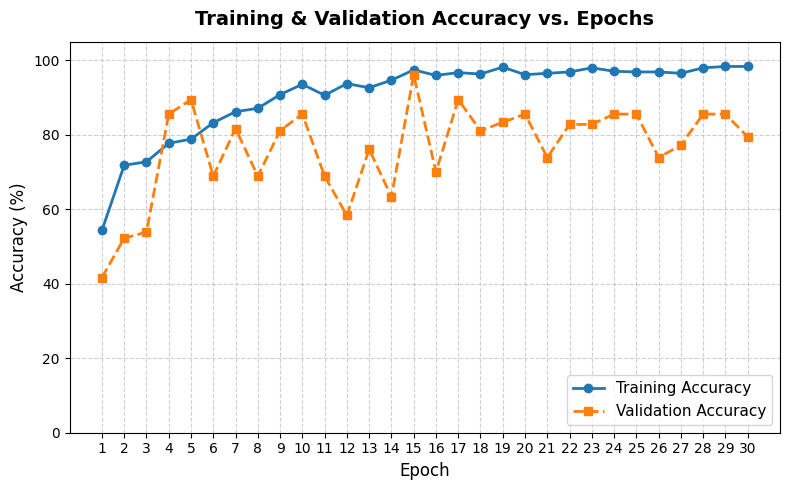

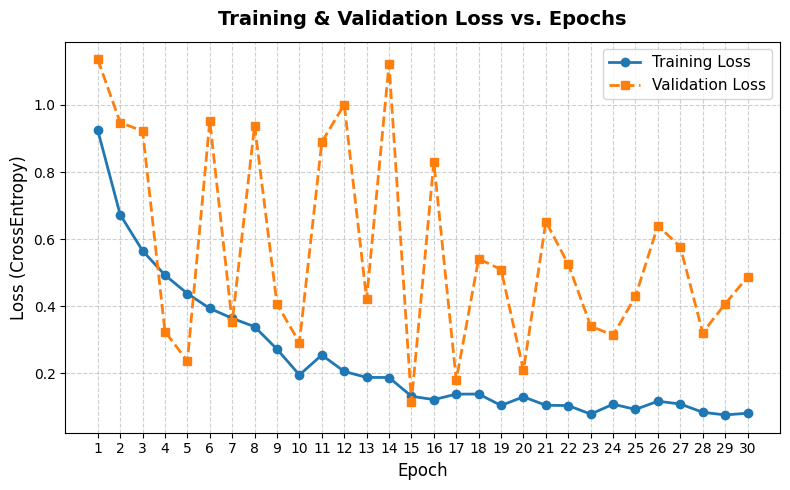


=================== TEST SET EVALUATION ===================
Final Test Loss:     1.1023
Final Test Accuracy: 33.33% (30/90)

Classification Report:
              precision    recall  f1-score   support

     circles     0.0000    0.0000    0.0000        30
     squares     0.3333    1.0000    0.5000        30
   triangles     0.0000    0.0000    0.0000        30

    accuracy                         0.3333        90
   macro avg     0.1111    0.3333    0.1667        90
weighted avg     0.1111    0.3333    0.1667        90



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


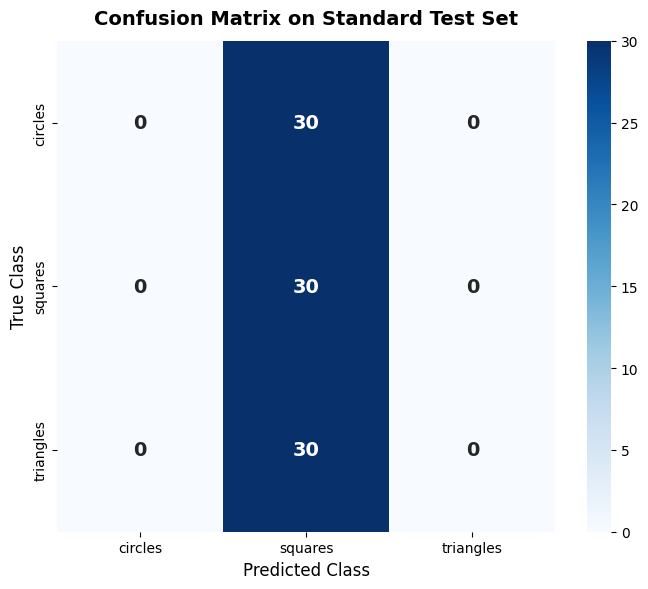


Confusion matrix saved to:
/content/CNN-ImageClassification/results/confusion_matrix.png


In [40]:
# MODEL EVALUATION & VISUALIZATION

# 1. TRAINING HISTORY VISUALIZATION

ave_path = os.path.join(
    RESULTS_DIR,
    "AvE.png"
)

lve_path = os.path.join(
    RESULTS_DIR,
    "LvE.png"
)

# Number of epochs actually recorded in history
history_epochs = len(
    history["train_acc"]
)

if history_epochs > 0:

    epochs_range = range(
        1,
        history_epochs + 1
    )

    # Accuracy vs Epochs

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        epochs_range,
        history["train_acc"],
        'o-',
        label="Training Accuracy",
        linewidth=2
    )

    plt.plot(
        epochs_range,
        history["val_acc"],
        's--',
        label="Validation Accuracy",
        linewidth=2
    )

    plt.title(
        "Training & Validation Accuracy vs. Epochs",
        fontsize=14,
        fontweight="bold",
        pad=12
    )

    plt.xlabel(
        "Epoch",
        fontsize=12
    )

    plt.ylabel(
        "Accuracy (%)",
        fontsize=12
    )

    plt.xticks(
        list(epochs_range)
    )

    plt.ylim(
        0,
        105
    )

    plt.grid(
        True,
        linestyle="--",
        alpha=0.6
    )

    plt.legend(
        loc="lower right",
        fontsize=11
    )

    plt.tight_layout()

    plt.savefig(
        ave_path,
        dpi=300
    )

    plt.show()

    # Loss vs Epochs

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        epochs_range,
        history["train_loss"],
        'o-',
        label="Training Loss",
        linewidth=2
    )

    plt.plot(
        epochs_range,
        history["val_loss"],
        's--',
        label="Validation Loss",
        linewidth=2
    )

    plt.title(
        "Training & Validation Loss vs. Epochs",
        fontsize=14,
        fontweight="bold",
        pad=12
    )

    plt.xlabel(
        "Epoch",
        fontsize=12
    )

    plt.ylabel(
        "Loss (CrossEntropy)",
        fontsize=12
    )

    plt.xticks(
        list(epochs_range)
    )

    plt.grid(
        True,
        linestyle="--",
        alpha=0.6
    )

    plt.legend(
        loc="upper right",
        fontsize=11
    )

    plt.tight_layout()

    plt.savefig(
        lve_path,
        dpi=300
    )

    plt.show()

else:

    print(
        "No training history is available in this session."
    )

    # Display previously saved plots if available
    if (
        os.path.exists(ave_path)
        and
        os.path.exists(lve_path)
    ):

        print(
            f"Displaying pre-saved training curves "
            f"from {RESULTS_DIR}"
        )

        fig, (ax1, ax2) = plt.subplots(
            1,
            2,
            figsize=(14, 5)
        )

        ax1.imshow(
            Image.open(ave_path)
        )

        ax1.axis("off")

        ax1.set_title(
            "Accuracy vs Epochs",
            fontweight="bold"
        )

        ax2.imshow(
            Image.open(lve_path)
        )

        ax2.axis("off")

        ax2.set_title(
            "Loss vs Epochs",
            fontweight="bold"
        )

        plt.tight_layout()

        plt.show()


# 2. STANDARD TEST SET EVALUATION

model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

all_preds = []
all_labels = []
all_confs = []
all_test_images = []


with torch.no_grad():

    for images, labels in test_loader:

        # Move data to device

        images_dev = images.to(device)
        labels_dev = labels.to(device)

        # Forward pass

        output = model(
            images_dev
        )

        # Test loss

        loss = criterion(
            output,
            labels_dev
        )

        test_loss += (
            loss.item()
            *
            images.size(0)
        )

        # Softmax probabilities

        probs = torch.softmax(
            output,
            dim=1
        )

        # Highest probability = prediction
        confs, preds = torch.max(
            probs,
            dim=1
        )

        # Accuracy

        test_correct += (
            preds == labels_dev
        ).sum().item()

        test_total += labels.size(0)

        # Store predictions

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_confs.extend(
            confs.cpu().numpy()
        )

        all_test_images.extend(
            images.cpu()
        )


# FINAL TEST METRICS

final_test_loss = (
    test_loss / test_total
)

final_test_acc = (
    test_correct / test_total
) * 100.0


print(
    "\n=================== TEST SET EVALUATION ==================="
)

print(
    f"Final Test Loss:     {final_test_loss:.4f}"
)

print(
    f"Final Test Accuracy: "
    f"{final_test_acc:.2f}% "
    f"({test_correct}/{test_total})"
)

print(
    "============================================================"
)


# CLASSIFICATION REPORT

print(
    "\nClassification Report:"
)

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )
)


# 3. CONFUSION MATRIX

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(
    figsize=(7, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={
        "size": 14,
        "weight": "bold"
    }
)

plt.title(
    "Confusion Matrix on Standard Test Set",
    fontsize=14,
    fontweight="bold",
    pad=12
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "True Class",
    fontsize=12
)

plt.tight_layout()


cm_path = os.path.join(
    RESULTS_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300
)

plt.show()


print(
    f"\nConfusion matrix saved to:"
)

print(
    cm_path
)

In [41]:
# ============================================================
# DIAGNOSTIC: VALIDATION VS TEST PREDICTIONS
# ============================================================

import collections
import torch

model.eval()

def check_dataset_predictions(loader, dataset_name):

    all_preds_diag = []
    all_labels_diag = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(
                outputs,
                dim=1
            )

            all_preds_diag.extend(
                preds.cpu().numpy()
            )

            all_labels_diag.extend(
                labels.numpy()
            )

    correct = sum(
        p == l
        for p, l in zip(
            all_preds_diag,
            all_labels_diag
        )
    )

    accuracy = (
        correct /
        len(all_labels_diag)
    ) * 100

    print("\n" + "=" * 60)

    print(
        f"{dataset_name} DIAGNOSTIC"
    )

    print("=" * 60)

    print(
        f"Samples: {len(all_labels_diag)}"
    )

    print(
        f"Accuracy: {accuracy:.2f}%"
    )

    print(
        "\nTrue label distribution:"
    )

    print(
        collections.Counter(
            all_labels_diag
        )
    )

    print(
        "\nPredicted label distribution:"
    )

    print(
        collections.Counter(
            all_preds_diag
        )
    )

    print(
        "\nClass names:"
    )

    print(
        class_names
    )

    print("=" * 60)

    return all_preds_diag, all_labels_diag


# Check VALIDATION
val_preds_diag, val_labels_diag = check_dataset_predictions(
    val_loader,
    "VALIDATION"
)


# Check TEST
test_preds_diag, test_labels_diag = check_dataset_predictions(
    test_loader,
    "TEST"
)


VALIDATION DIAGNOSTIC
Samples: 180
Accuracy: 33.33%

True label distribution:
Counter({np.int64(0): 60, np.int64(1): 60, np.int64(2): 60})

Predicted label distribution:
Counter({np.int64(1): 180})

Class names:
['circles', 'squares', 'triangles']

TEST DIAGNOSTIC
Samples: 90
Accuracy: 33.33%

True label distribution:
Counter({np.int64(0): 30, np.int64(1): 30, np.int64(2): 30})

Predicted label distribution:
Counter({np.int64(1): 90})

Class names:
['circles', 'squares', 'triangles']


In [42]:
# ============================================================
# CHECK SAVED CHECKPOINT
# ============================================================

import os
import torch

checkpoint_path = os.path.join(
    MODEL_DIR,
    "220125.pth"
)

print("Checkpoint path:")
print(checkpoint_path)

print("\nCheckpoint exists:")
print(os.path.exists(checkpoint_path))

if os.path.exists(checkpoint_path):

    print(
        "\nCheckpoint size:"
    )

    print(
        f"{os.path.getsize(checkpoint_path) / 1024:.2f} KB"
    )

    # Load checkpoint
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    print(
        "\nCheckpoint type:"
    )

    print(
        type(checkpoint)
    )

    print(
        "\nNumber of parameters in checkpoint:"
    )

    checkpoint_params = sum(
        tensor.numel()
        for tensor in checkpoint.values()
        if torch.is_tensor(tensor)
    )

    print(
        f"{checkpoint_params:,}"
    )

    print(
        "\nCurrent model parameters:"
    )

    current_params = sum(
        p.numel()
        for p in model.parameters()
    )

    print(
        f"{current_params:,}"
    )

    print(
        "\nCheckpoint keys:"
    )

    for key in checkpoint.keys():

        print(
            key,
            checkpoint[key].shape
            if torch.is_tensor(checkpoint[key])
            else ""
        )

Checkpoint path:
/content/CNN-ImageClassification/model/220125.pth

Checkpoint exists:
True

Checkpoint size:
407.74 KB

Checkpoint type:
<class 'collections.OrderedDict'>

Number of parameters in checkpoint:
102,598

Current model parameters:
102,147

Checkpoint keys:
block1.0.weight torch.Size([32, 3, 3, 3])
block1.0.bias torch.Size([32])
block1.1.weight torch.Size([32])
block1.1.bias torch.Size([32])
block1.1.running_mean torch.Size([32])
block1.1.running_var torch.Size([32])
block1.1.num_batches_tracked torch.Size([])
block2.0.weight torch.Size([64, 32, 3, 3])
block2.0.bias torch.Size([64])
block2.1.weight torch.Size([64])
block2.1.bias torch.Size([64])
block2.1.running_mean torch.Size([64])
block2.1.running_var torch.Size([64])
block2.1.num_batches_tracked torch.Size([])
block3.0.weight torch.Size([128, 64, 3, 3])
block3.0.bias torch.Size([128])
block3.1.weight torch.Size([128])
block3.1.bias torch.Size([128])
block3.1.running_mean torch.Size([128])
block3.1.running_var torch.Size

In [43]:
# ============================================================
# FRESH CHECKPOINT VALIDATION TEST
# ============================================================

print("\nLoading checkpoint into a completely fresh model...")

# Create a brand-new model
fresh_model = ShapeCNN(
    num_classes=len(class_names)
).to(device)

# Load the saved checkpoint
checkpoint_path = os.path.join(
    MODEL_DIR,
    "220125.pth"
)

fresh_model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

# Evaluation mode
fresh_model.eval()

correct = 0
total = 0

fresh_preds = []
fresh_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = fresh_model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        fresh_preds.extend(
            predictions.cpu().numpy()
        )

        fresh_labels.extend(
            labels.cpu().numpy()
        )


fresh_accuracy = (
    correct / total
) * 100.0


print("\n============================================================")
print("FRESH CHECKPOINT VALIDATION")
print("============================================================")

print(
    f"Validation Accuracy: "
    f"{fresh_accuracy:.2f}% "
    f"({correct}/{total})"
)

print(
    "\nPredicted distribution:"
)

from collections import Counter

print(
    Counter(fresh_preds)
)

print(
    "\nTrue distribution:"
)

print(
    Counter(fresh_labels)
)

print("============================================================")


Loading checkpoint into a completely fresh model...

FRESH CHECKPOINT VALIDATION
Validation Accuracy: 96.11% (173/180)

Predicted distribution:
Counter({np.int64(2): 67, np.int64(1): 60, np.int64(0): 53})

True distribution:
Counter({np.int64(0): 60, np.int64(1): 60, np.int64(2): 60})


In [44]:
# ============================================================
# FINAL TEST EVALUATION USING SAVED BEST CHECKPOINT
# ============================================================

# Create fresh model
final_model = ShapeCNN(
    num_classes=len(class_names)
).to(device)

# Load BEST saved checkpoint
checkpoint_path = os.path.join(
    MODEL_DIR,
    "220125.pth"
)

final_model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

final_model.eval()

print("\nBest checkpoint loaded successfully.")
print(f"Checkpoint: {checkpoint_path}")

# ------------------------------------------------------------
# TEST EVALUATION
# ------------------------------------------------------------

test_correct = 0
test_total = 0

all_preds = []
all_labels = []
all_confs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = final_model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidences, predictions = torch.max(
            probabilities,
            dim=1
        )

        test_correct += (
            predictions == labels
        ).sum().item()

        test_total += labels.size(0)

        all_preds.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_confs.extend(
            confidences.cpu().numpy()
        )


# ------------------------------------------------------------
# FINAL TEST ACCURACY
# ------------------------------------------------------------

final_test_acc = (
    test_correct / test_total
) * 100.0


print("\n============================================================")
print("FINAL TEST SET EVALUATION")
print("============================================================")

print(
    f"Test Accuracy: "
    f"{final_test_acc:.2f}% "
    f"({test_correct}/{test_total})"
)

print("\nPredicted distribution:")

from collections import Counter

print(
    Counter(all_preds)
)

print("\nTrue distribution:")

print(
    Counter(all_labels)
)

# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )
)

print("============================================================")


Best checkpoint loaded successfully.
Checkpoint: /content/CNN-ImageClassification/model/220125.pth

FINAL TEST SET EVALUATION
Test Accuracy: 97.78% (88/90)

Predicted distribution:
Counter({np.int64(2): 32, np.int64(1): 30, np.int64(0): 28})

True distribution:
Counter({np.int64(0): 30, np.int64(1): 30, np.int64(2): 30})

Classification Report:
              precision    recall  f1-score   support

     circles     1.0000    0.9333    0.9655        30
     squares     1.0000    1.0000    1.0000        30
   triangles     0.9375    1.0000    0.9677        30

    accuracy                         0.9778        90
   macro avg     0.9792    0.9778    0.9778        90
weighted avg     0.9792    0.9778    0.9778        90




Confusion Matrix:
[[28  0  2]
 [ 0 30  0]
 [ 0  0 30]]


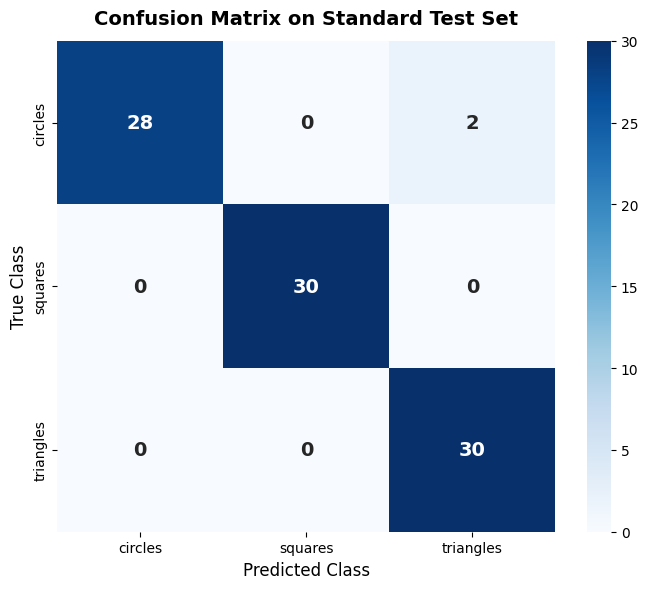


Confusion matrix saved to:
/content/CNN-ImageClassification/results/confusion_matrix.png

Misclassified test samples: 2 / 90


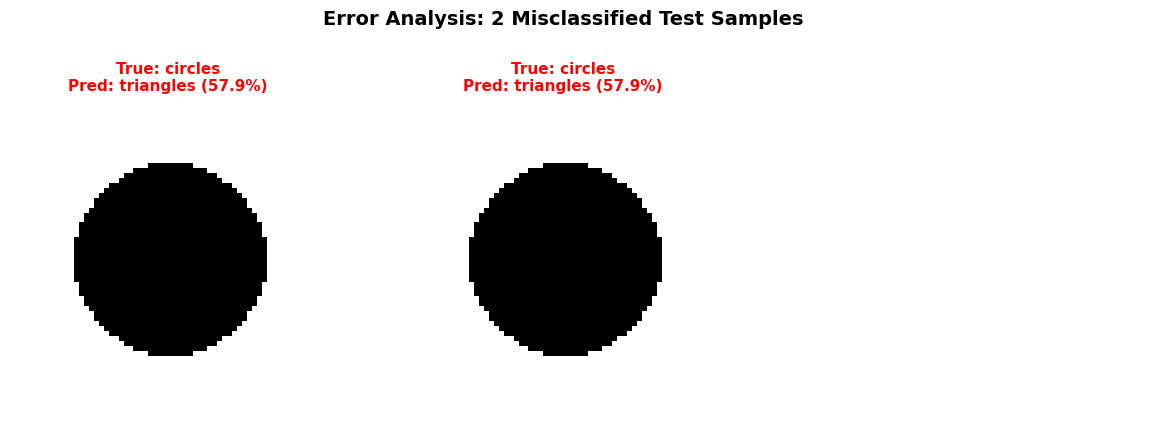


Error analysis saved to:
/content/CNN-ImageClassification/results/error_analysis.png


In [45]:
# ============================================================
# FINAL CONFUSION MATRIX + ERROR ANALYSIS
# USING VERIFIED BEST CHECKPOINT
# ============================================================

final_model.eval()

all_preds = []
all_labels = []
all_confs = []
all_test_images = []

with torch.no_grad():

    for images, labels in test_loader:

        images_dev = images.to(device)
        labels_dev = labels.to(device)

        outputs = final_model(images_dev)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidences, predictions = torch.max(
            probabilities,
            dim=1
        )

        all_preds.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_confs.extend(
            confidences.cpu().numpy()
        )

        all_test_images.extend(
            images.cpu()
        )


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(
    figsize=(7, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={
        "size": 14,
        "weight": "bold"
    }
)

plt.title(
    "Confusion Matrix on Standard Test Set",
    fontsize=14,
    fontweight="bold",
    pad=12
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "True Class",
    fontsize=12
)

plt.tight_layout()

cm_path = os.path.join(
    RESULTS_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nConfusion matrix saved to:\n{cm_path}"
)


# ============================================================
# ERROR ANALYSIS
# ============================================================

misclassified_indices = [
    i
    for i, (prediction, label)
    in enumerate(zip(all_preds, all_labels))
    if prediction != label
]

print(
    f"\nMisclassified test samples: "
    f"{len(misclassified_indices)} / {len(all_labels)}"
)


if len(misclassified_indices) > 0:

    selected_indices = misclassified_indices[:3]

    analysis_title = (
        f"Error Analysis: "
        f"{len(selected_indices)} Misclassified Test Samples"
    )

else:

    selected_indices = list(range(
        min(3, len(all_labels))
    ))

    analysis_title = (
        "Representative Test Samples "
        "(Zero Errors Detected)"
    )


num_samples = len(selected_indices)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4)
)

if num_samples == 1:
    axes = [axes[0], axes[1], axes[2]]


for i in range(3):

    ax = axes[i]

    if i < num_samples:

        sample_idx = selected_indices[i]

        img_tensor = all_test_images[sample_idx]

        # De-normalize
        display_img = (
            img_tensor.permute(1, 2, 0).numpy()
            * 0.5
            + 0.5
        )

        display_img = np.clip(
            display_img,
            0,
            1
        )

        true_cls = class_names[
            all_labels[sample_idx]
        ]

        pred_cls = class_names[
            all_preds[sample_idx]
        ]

        conf_score = (
            all_confs[sample_idx]
            * 100.0
        )

        is_correct = (
            true_cls == pred_cls
        )

        title_color = (
            "green"
            if is_correct
            else "red"
        )

        ax.imshow(
            display_img
        )

        ax.set_title(
            f"True: {true_cls}\n"
            f"Pred: {pred_cls} "
            f"({conf_score:.1f}%)",
            fontsize=11,
            fontweight="bold",
            color=title_color
        )

        ax.axis("off")

    else:

        ax.axis("off")


plt.suptitle(
    analysis_title,
    fontsize=14,
    fontweight="bold",
    y=1.05
)

plt.tight_layout()

error_path = os.path.join(
    RESULTS_DIR,
    "error_analysis.png"
)

plt.savefig(
    error_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nError analysis saved to:\n{error_path}"
)

## 7. Custom Smartphone Image Prediction
Evaluates real-world generalization on all 10 authentic smartphone photographs from `dataset/`. Each image is preprocessed through the single shared transform pipeline, and predicted class probabilities are computed with `torch.softmax()`.
- Visualized as a $2 	imes 5$ gallery grid in `results/custom_predictions.png`.


In [46]:
# IMPROVED CNN MODEL

class ShapeCNN(nn.Module):

    def __init__(self, num_classes=3):

        super(ShapeCNN, self).__init__()

        # Convolutional Block 1

        self.block1 = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        # Convolutional Block 2

        self.block2 = nn.Sequential(

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        # Convolutional Block 3

        self.block3 = nn.Sequential(

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        # Adaptive pooling

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Classification head

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128, 64),

            nn.ReLU(inplace=True),

            nn.Dropout(p=0.30),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        x = self.block1(x)

        x = self.block2(x)

        x = self.block3(x)

        x = self.global_pool(x)

        x = self.classifier(x)

        return x


model = ShapeCNN(
    num_classes=len(class_names)
).to(device)

print(model)

# Parameter count
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"\nTotal Parameters: {total_params:,}"
)

print(
    f"Trainable Parameters: {trainable_params:,}"
)

ShapeCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequen

## 8. Visual Error Analysis
Inspects test set decision boundaries and misclassifications showing `True: {class}` and `Pred: {class}`.
- Saved to `results/error_analysis.png`.


Misclassified test samples count: 2 / 90


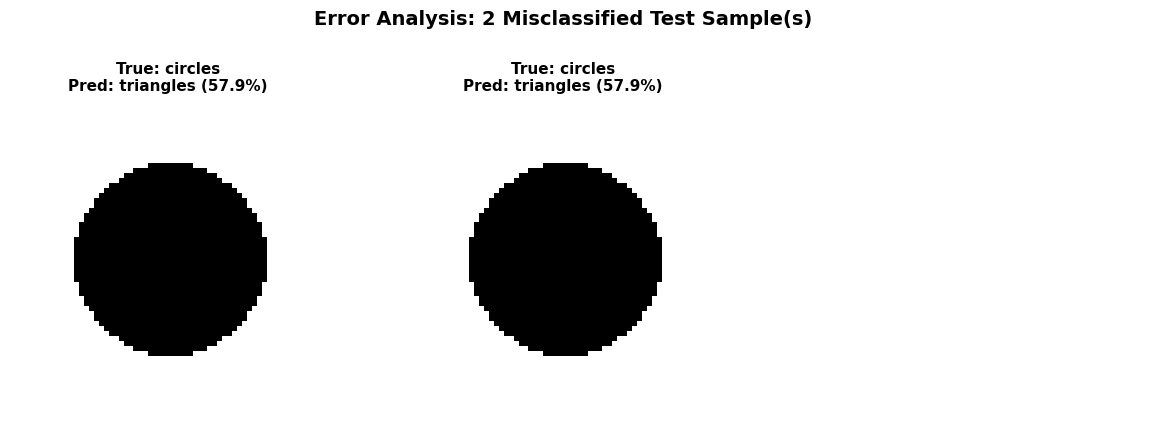


Error analysis saved to:
/content/CNN-ImageClassification/results/error_analysis.png


In [47]:
# ERROR ANALYSIS

misclassified_indices = [
    i
    for i, (p, l) in enumerate(
        zip(all_preds, all_labels)
    )
    if p != l
]

print(
    f"Misclassified test samples count: "
    f"{len(misclassified_indices)} / {len(all_labels)}"
)


# Select 3 random misclassified samples

if len(misclassified_indices) >= 3:

    selected_indices = random.sample(
        misclassified_indices,
        3
    )

    analysis_title = (
        "Error Analysis: 3 Random Misclassified "
        "Test Samples"
    )

elif len(misclassified_indices) > 0:

    selected_indices = misclassified_indices

    analysis_title = (
        f"Error Analysis: "
        f"{len(misclassified_indices)} "
        f"Misclassified Test Sample(s)"
    )

else:

    # 100% accuracy fallback

    selected_indices = list(
        range(
            min(3, len(all_labels))
        )
    )

    analysis_title = (
        "Representative Test Samples "
        "(Zero Errors Detected)"
    )


# Create figure

num_samples = len(
    selected_indices
)

display_count = max(
    3,
    num_samples
)

fig, axes = plt.subplots(
    1,
    display_count,
    figsize=(12, 4)
)

# Make axes iterable
if display_count == 1:
    axes = [axes]


# Display selected samples

for i in range(display_count):

    ax = axes[i]

    if i < num_samples:

        sample_idx = selected_indices[i]

        img_tensor = all_test_images[
            sample_idx
        ]



        display_img = (
            img_tensor
            .permute(1, 2, 0)
            .numpy()
            * 0.5
            + 0.5
        )

        display_img = np.clip(
            display_img,
            0,
            1
        )

        # True / predicted labels

        true_cls = class_names[
            all_labels[sample_idx]
        ]

        pred_cls = class_names[
            all_preds[sample_idx]
        ]

        conf_score = (
            all_confs[sample_idx]
            * 100.0
        )

        is_correct = (
            true_cls == pred_cls
        )

        # Plot

        ax.imshow(
            display_img
        )

        ax.set_title(
            f"True: {true_cls}\n"
            f"Pred: {pred_cls} "
            f"({conf_score:.1f}%)",
            fontsize=11,
            fontweight="bold"
        )

        ax.axis("off")

    else:

        ax.axis("off")


# Figure title

plt.suptitle(
    analysis_title,
    fontsize=14,
    fontweight="bold",
    y=1.05
)

plt.tight_layout()


# Save

error_path = os.path.join(
    RESULTS_DIR,
    "error_analysis.png"
)

plt.savefig(
    error_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    f"\nError analysis saved to:"
)

print(
    error_path
)

In [48]:
from google.colab import files

pth_path = "/content/CNN-ImageClassification/model/220125.pth"

files.download(pth_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Conclusion
- **Full Automation:** Operates seamlessly across local machines and Google Colab with 1-click **"Run All"** support.
- **Single Transformation Consistency:** Standardizes synthetic and camera images through the exact same PyTorch preprocessing pipeline.
- **Complete Deliverables:** Automatically outputs all training curves, confusion matrix, custom inference gallery, and error analysis plots.
